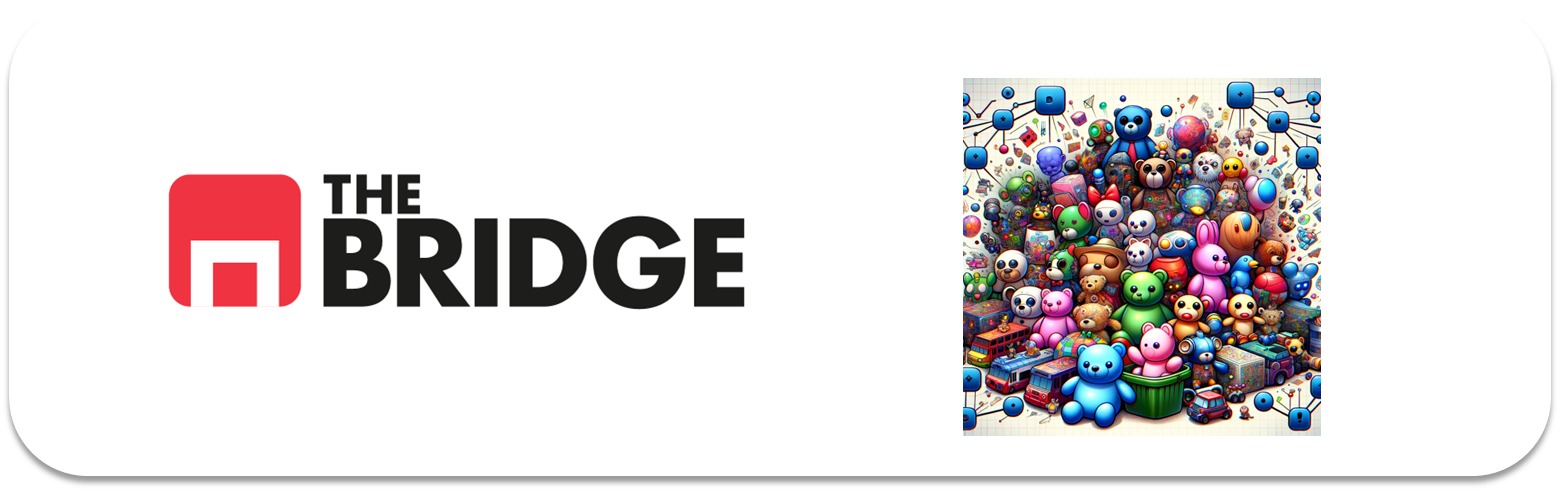

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bvt

from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, accuracy_score

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [2]:
# 2. Cargamos los datos. El CSV viene separado por "|"
df = pd.read_csv("./data/empowering_drinks.csv", sep="|")

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (153, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [3]:
# Info general y estadisticos
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


Tenemos 153 mezclas y 5 componentes (features), todas numéricas y sin valores nulos. Fijándonos en el `describe`, las medias rondan 0 y las desviaciones típicas rondan 1: **los datos ya vienen estandarizados**, así que no hará falta escalar.

In [4]:
# Lista de features (todas las columnas son numericas)
features = df.columns.tolist()
print(features)

['Azúcares', 'Vitamínas del grupo B', 'Cafeína', 'Ácido Cítrico', 'Taurina']


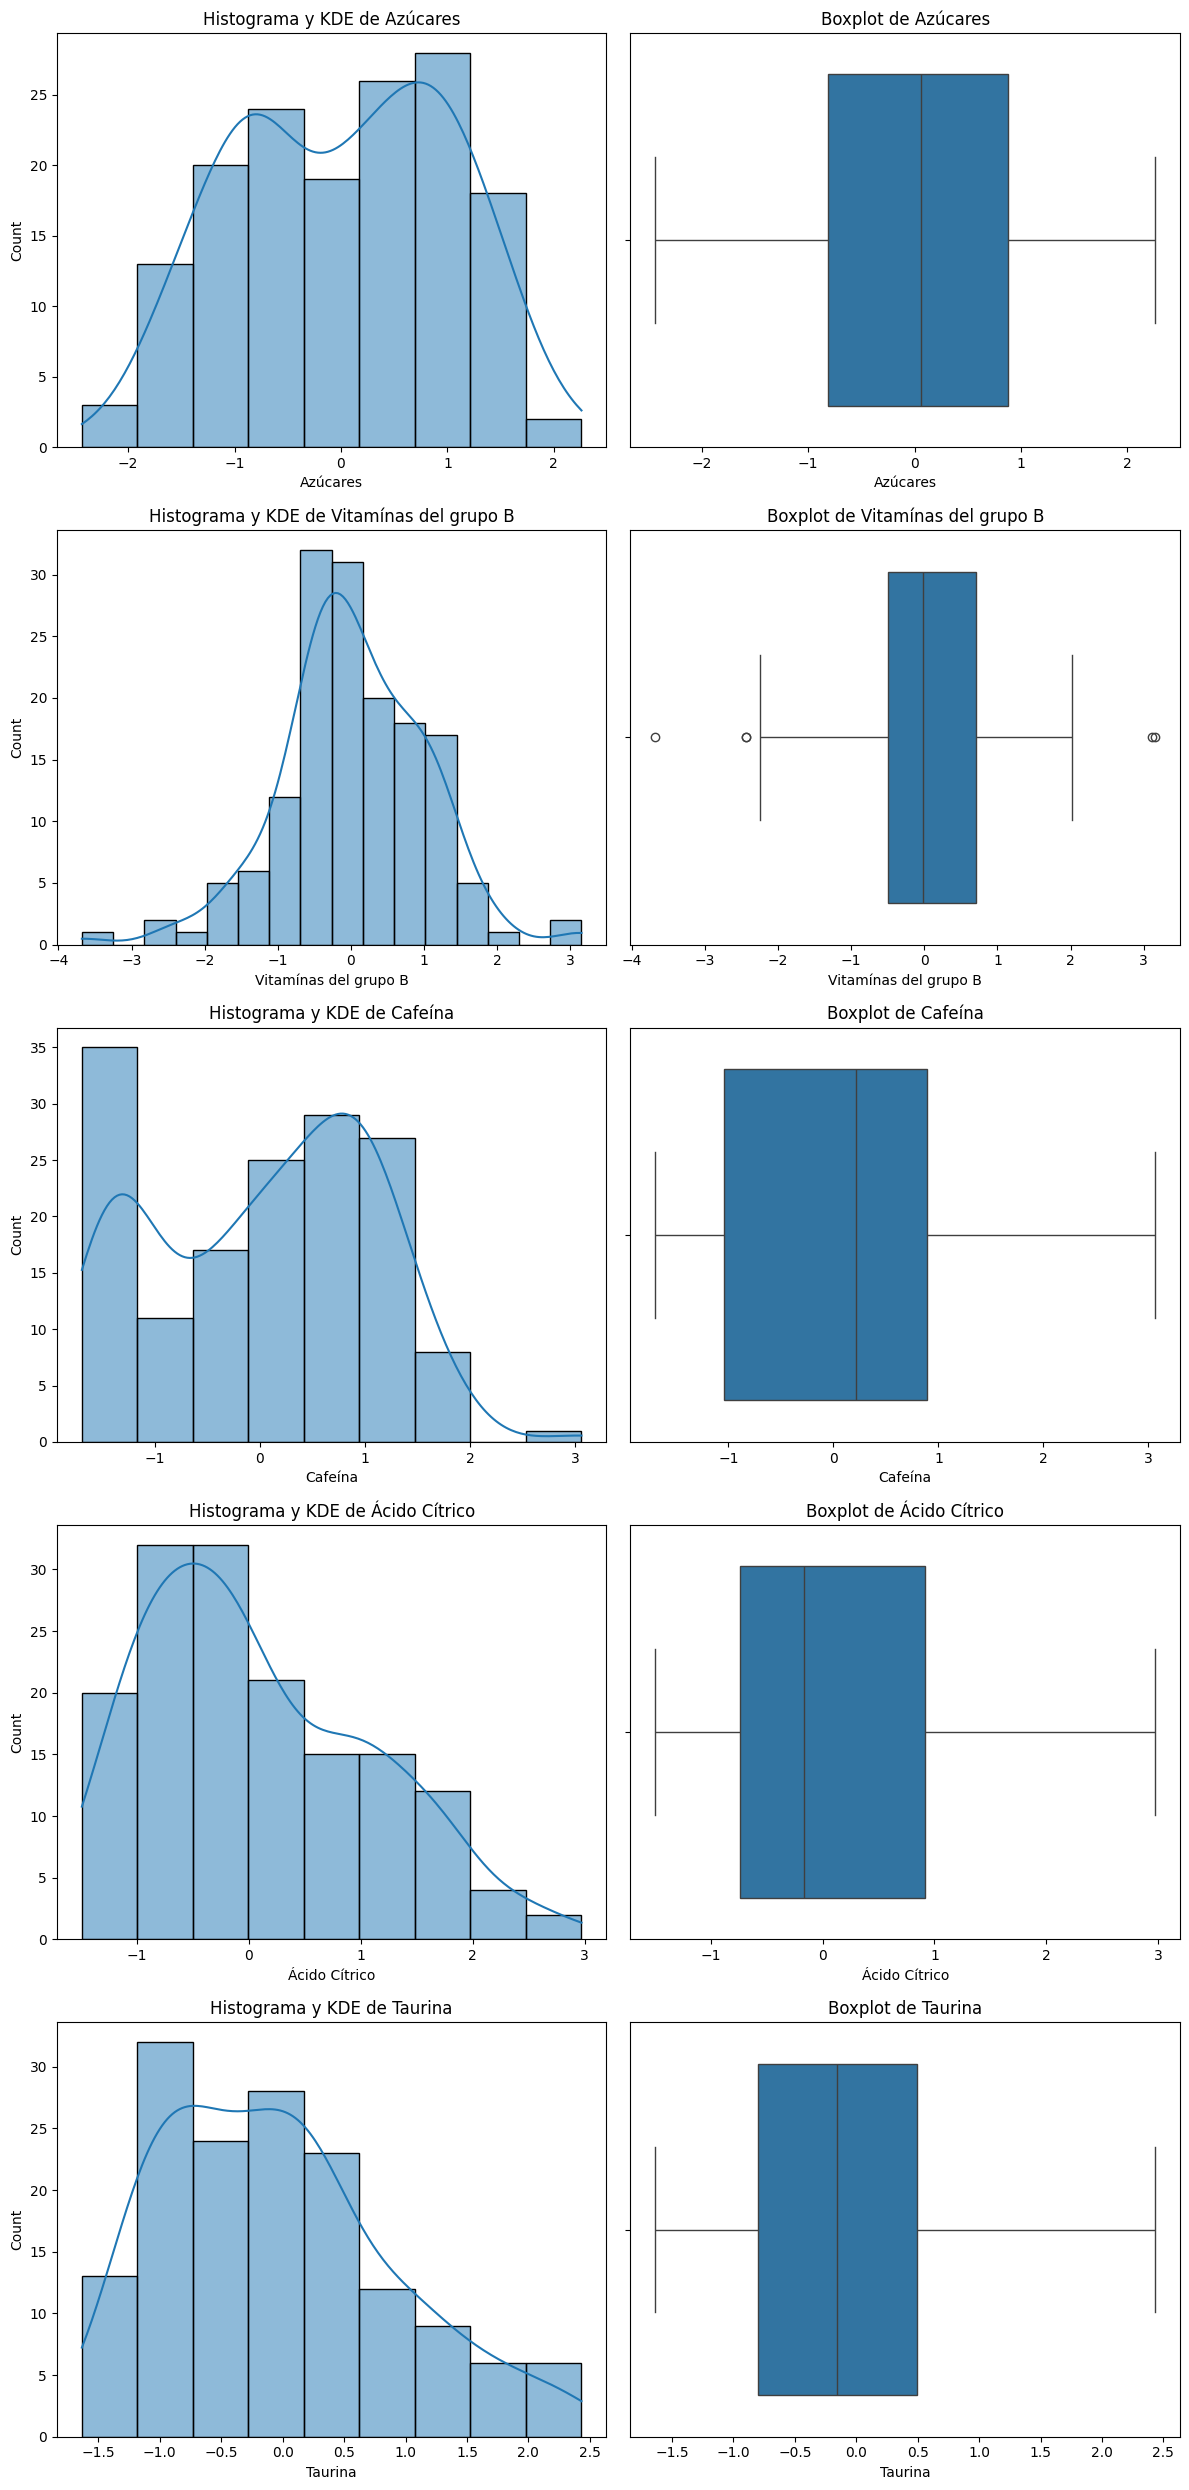

In [5]:
# Distribucion de cada componente: histograma + KDE y boxplot
bvt.plot_combined_graphs(df, features)

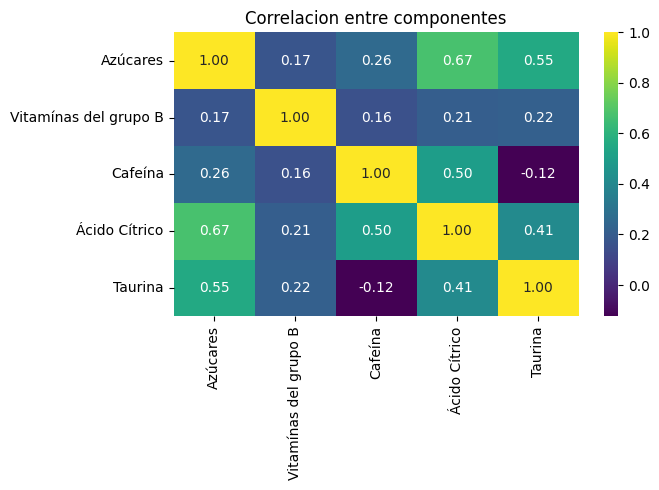

In [6]:
# Ahora las relaciones dos a dos con dispersión + correlación,
# para ver qué pares de componentes muestran estructura
# (grupos separados) y cuáles están muy correlacionados
# (redundantes).
# Matriz de correlacion para detectar features redundantes

plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlacion entre componentes")
plt.tight_layout()
plt.show()

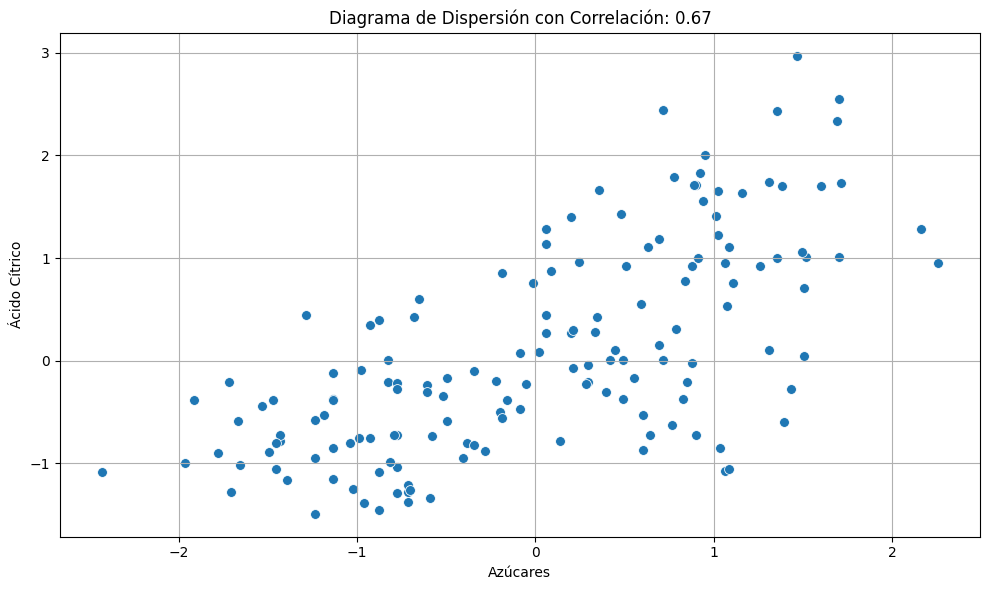

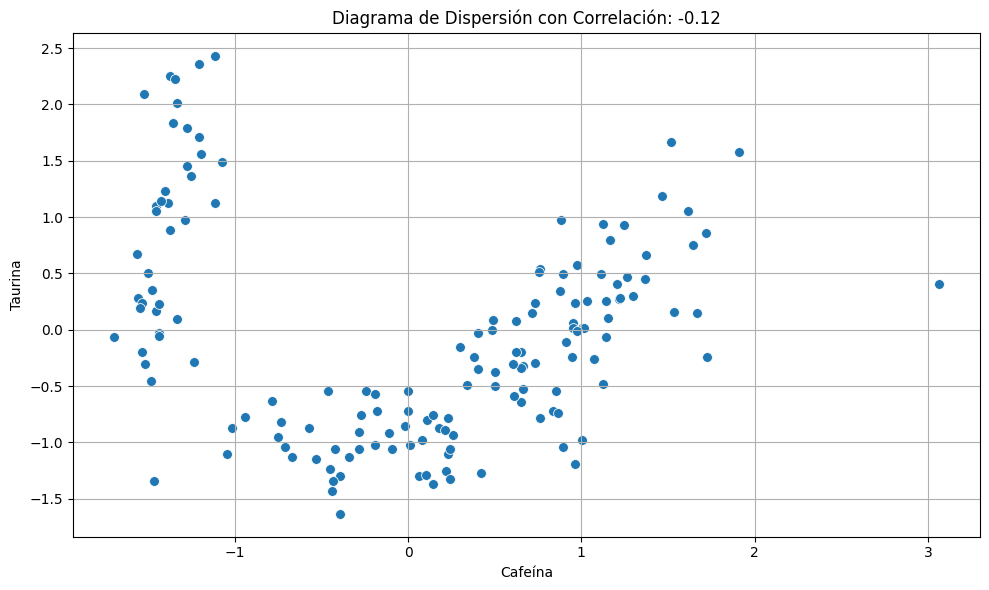

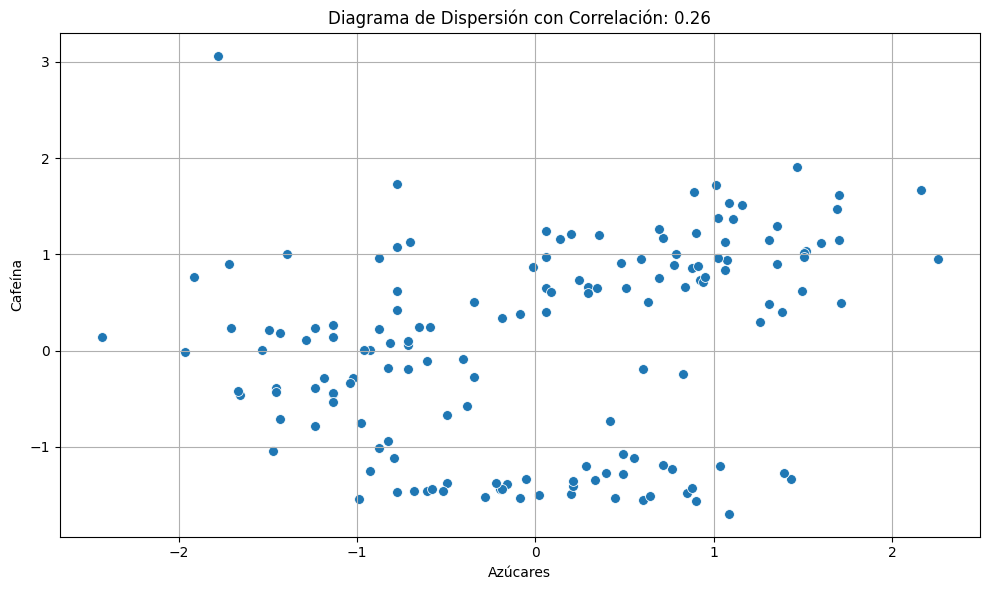

In [7]:
# Dispersiones dos a dos de algunos pares interesantes usando el viztool
# Azucares vs Acido Citrico (correlacion alta) y Cafeina vs Taurina (baja)
bvt.grafico_dispersion_con_correlacion(df, "Azúcares", "Ácido Cítrico", mostrar_correlacion=True)
bvt.grafico_dispersion_con_correlacion(df, "Cafeína", "Taurina", mostrar_correlacion=True)
bvt.grafico_dispersion_con_correlacion(df, "Azúcares", "Cafeína", mostrar_correlacion=True)

**Conclusión del mini-EDA:**

- `Azúcares`, `Ácido Cítrico` y `Taurina` están bastante correlacionadas entre sí (0.4–0.67), así que aportan información parecida.
- `Cafeína` y `Vitamínas del grupo B` son las más independientes del resto.
- En los diagramas de dispersión se intuye estructura (nubes de puntos que se separan), sobre todo en los ejes donde entra `Azúcares` / `Ácido Cítrico`.

Como solo tenemos 5 features y el enunciado dice que no hay que quedarse necesariamente en dos, **nos quedamos con todas**: son pocas, ya están escaladas y quitar alguna no simplifica gran cosa. Sí nos ha servido el EDA para entender que la separación principal va por el bloque azúcares/ácido cítrico/taurina.

In [8]:
# Los datos ya vienen estandarizados (media ~0, std ~1) y no hay nulos,
# así que no hace falta imputar ni escalar. Trabajamos directamente con
# la matriz de features.

X = df[features].values
X.shape

(153, 5)

**Selección de modelos e hiperparámetros**

El enunciado pide **al menos dos algoritmos, uno de ellos DBSCAN**. El otro "que debería estar claro" es el **clustering jerárquico (Agglomerative)**: además de segmentar, nos da una **relación entre segmentos** (qué grupos se parecen más), que es justo el extra que pedían los químicos. Un dendrograma responde a eso de forma natural.

Los químicos esperan **entre 3 y 5 segmentos**.

_Modelo A — Clustering jerárquico (Agglomerative + dendrograma)_

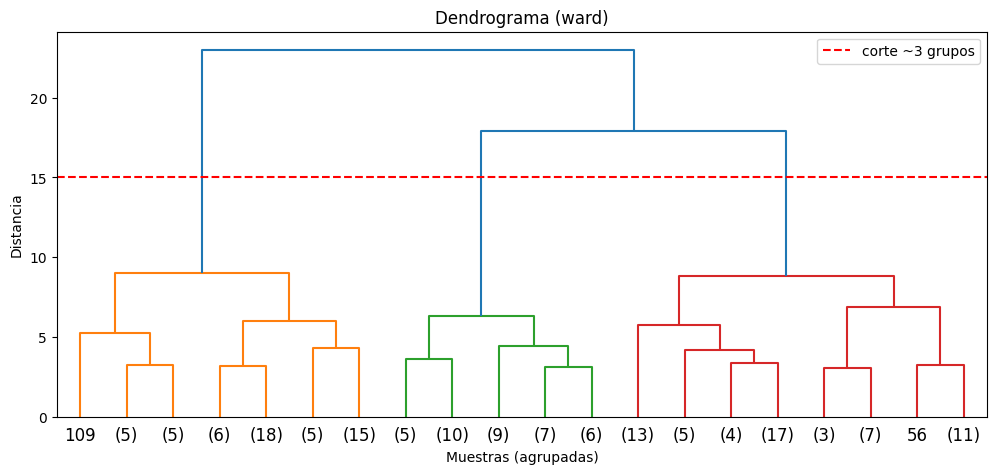

In [9]:
# Dendrograma para ver la estructura jerarquica y cuantos grupos tiene sentido cortar
Z = linkage(X, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=20)
plt.title("Dendrograma (ward)")
plt.xlabel("Muestras (agrupadas)")
plt.ylabel("Distancia")
plt.axhline(y=15, color="red", linestyle="--", label="corte ~3 grupos")
plt.legend()
plt.show()

In [10]:
# Probamos k = 3, 4, 5 (rango que esperan los quimicos) y miramos la silueta
for k in [3, 4, 5]:
    labels_k = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    print(f"k = {k}  ->  silueta = {silhouette_score(X, labels_k):.3f}")

k = 3  ->  silueta = 0.384
k = 4  ->  silueta = 0.337
k = 5  ->  silueta = 0.304


La silueta es máxima en **k=3**, que además coincide con lo que sugiere el dendrograma y con el mínimo que esperaban los químicos. Nos quedamos con **k=3**.

_Modelo B — DBSCAN_

DBSCAN necesita dos hiperparámetros: `eps` y `min_samples`. Una heurística habitual es fijar `min_samples ≈ 2 · nº_features = 10` y elegir `eps` con el "codo" de la curva de distancias al k-ésimo vecino.

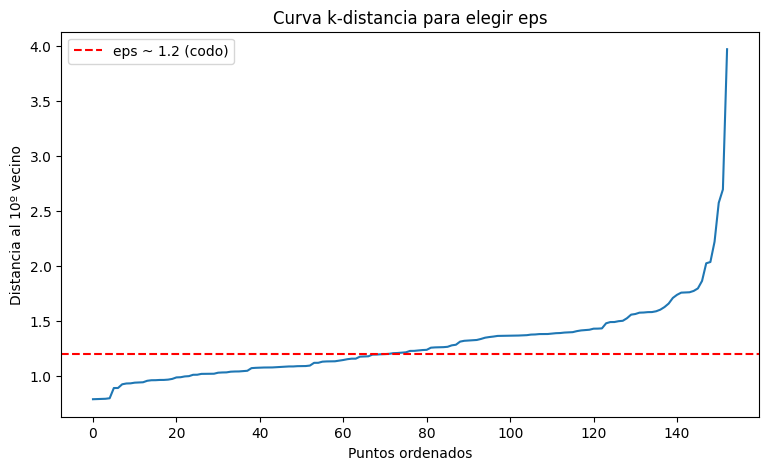

In [11]:
# Curva k-distancia para elegir eps (con min_samples = 10)
min_samples = 10
nn = NearestNeighbors(n_neighbors=min_samples).fit(X)
distancias, _ = nn.kneighbors(X)
k_dist = np.sort(distancias[:, -1])   # distancia al vecino nº min_samples

plt.figure(figsize=(9, 5))
plt.plot(k_dist)
plt.axhline(y=1.2, color="red", linestyle="--", label="eps ~ 1.2 (codo)")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {min_samples}º vecino")
plt.title("Curva k-distancia para elegir eps")
plt.legend()
plt.show()

In [12]:
# Probamos varios eps alrededor del codo y nos quedamos con el que de 3-5 clusters
print(f"{'eps':>5} | {'clusters':>8} | {'ruido':>6} | {'silueta':>8}")
print("-" * 36)
for eps in [1.0, 1.1, 1.2, 1.3, 1.4]:
    labels_db = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_ruido = (labels_db == -1).sum()
    if n_clusters > 1:
        sil = silhouette_score(X, labels_db)
        print(f"{eps:>5} | {n_clusters:>8} | {n_ruido:>6} | {sil:>8.3f}")
    else:
        print(f"{eps:>5} | {n_clusters:>8} | {n_ruido:>6} | {'NA':>8}")

  eps | clusters |  ruido |  silueta
------------------------------------
  1.0 |        2 |     88 |    0.122
  1.1 |        3 |     41 |    0.254
  1.2 |        3 |     22 |    0.337
  1.3 |        1 |     12 |       NA
  1.4 |        1 |      7 |       NA


Con `eps=1.2` y `min_samples=10` DBSCAN encuentra **3 clusters** (dentro del rango esperado) con la mejor silueta. Con `eps` más pequeño casi todo es ruido y con `eps` más grande colapsa en un solo grupo. Nos quedamos con **eps=1.2, min_samples=10**.

In [13]:
# Entrenamos los dos modelos definitivos
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_agg = agg.fit_predict(X)

dbscan = DBSCAN(eps=1.2, min_samples=10)
labels_db = dbscan.fit_predict(X)

print("Jerarquico (k=3) -> grupos:", np.bincount(labels_agg))
print("DBSCAN -> etiquetas:", dict(zip(*np.unique(labels_db, return_counts=True))), "(-1 = ruido)")

Jerarquico (k=3) -> grupos: [55 61 37]
DBSCAN -> etiquetas: {np.int64(-1): np.int64(22), np.int64(0): np.int64(51), np.int64(1): np.int64(49), np.int64(2): np.int64(31)} (-1 = ruido)


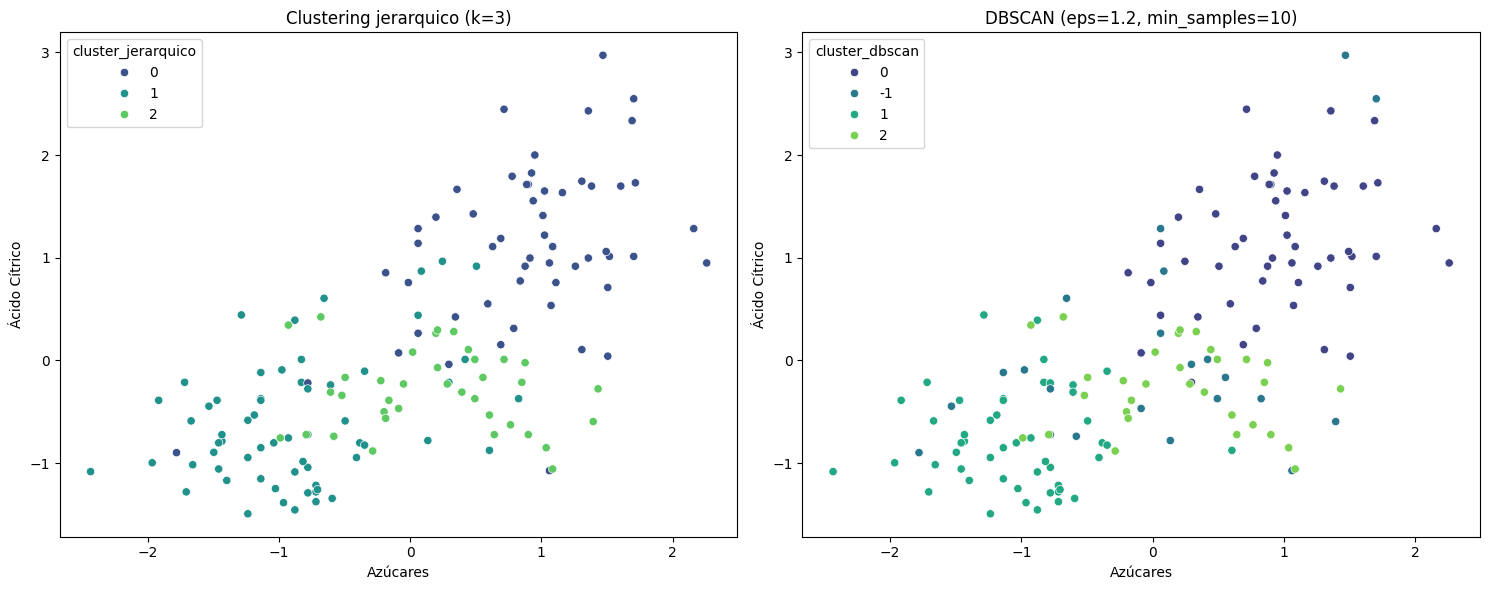

In [14]:
# Visualizamos los resultados sobre el par de features mas informativo (Azucares vs Acido Citrico)
# Anadimos las etiquetas al dataframe para pintarlas
df_plot = df.copy()
df_plot["cluster_jerarquico"] = labels_agg.astype(str)
df_plot["cluster_dbscan"] = labels_db.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df_plot, x="Azúcares", y="Ácido Cítrico",
                hue="cluster_jerarquico", palette="viridis", ax=axes[0])
axes[0].set_title("Clustering jerarquico (k=3)")

sns.scatterplot(data=df_plot, x="Azúcares", y="Ácido Cítrico",
                hue="cluster_dbscan", palette="viridis", ax=axes[1])
axes[1].set_title("DBSCAN (eps=1.2, min_samples=10)")

plt.tight_layout()
plt.show()

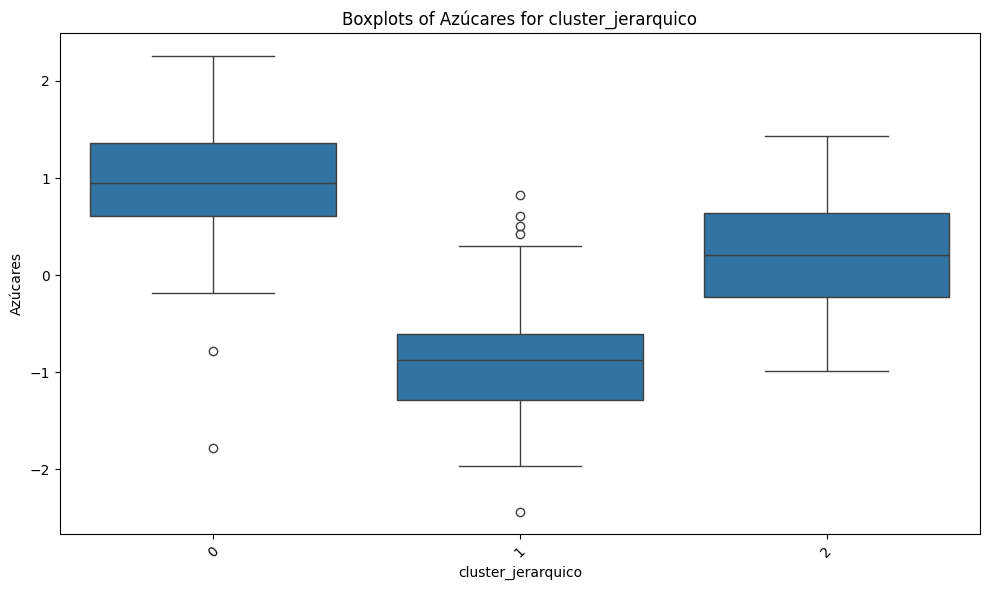

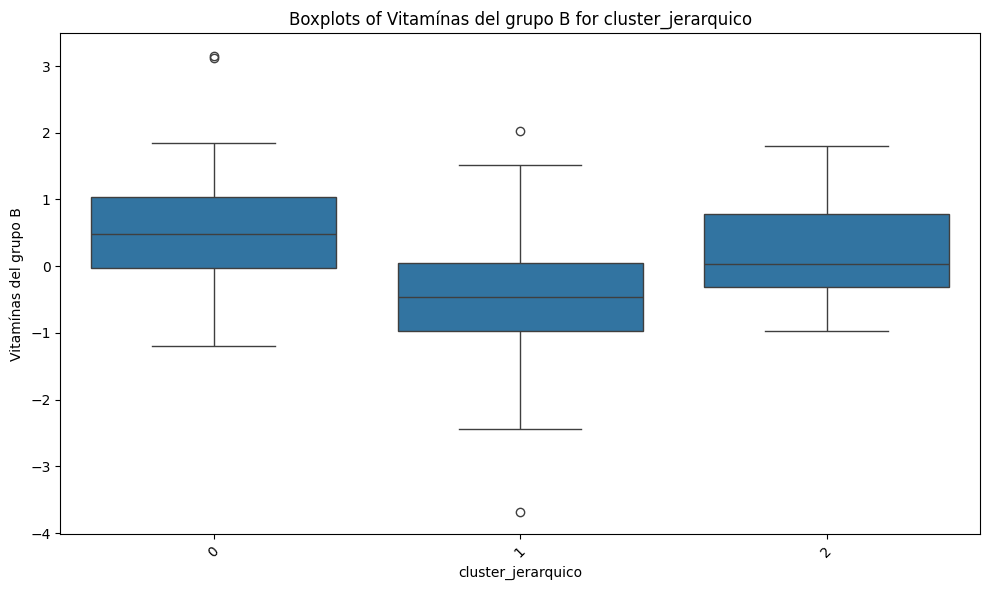

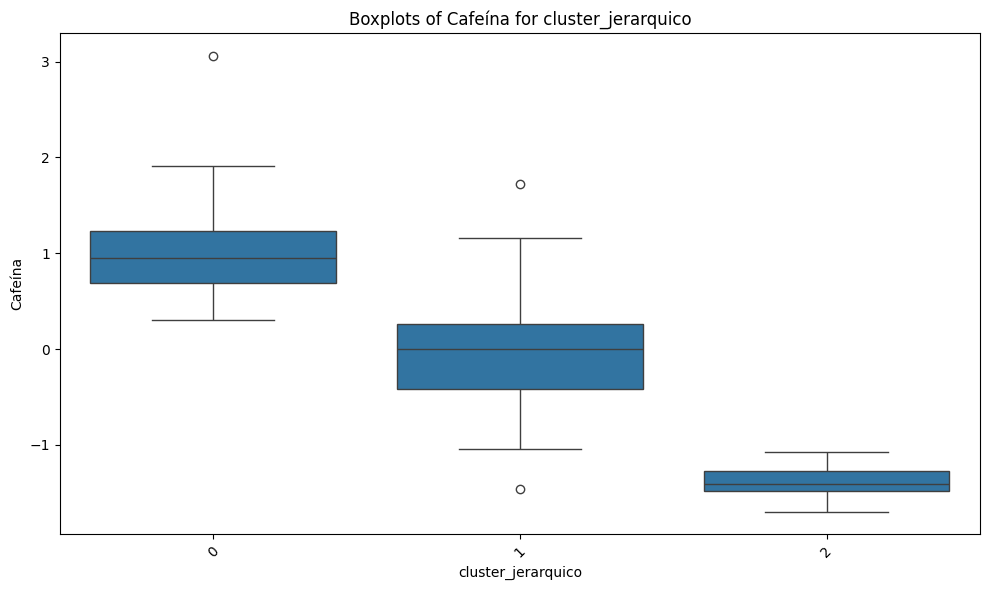

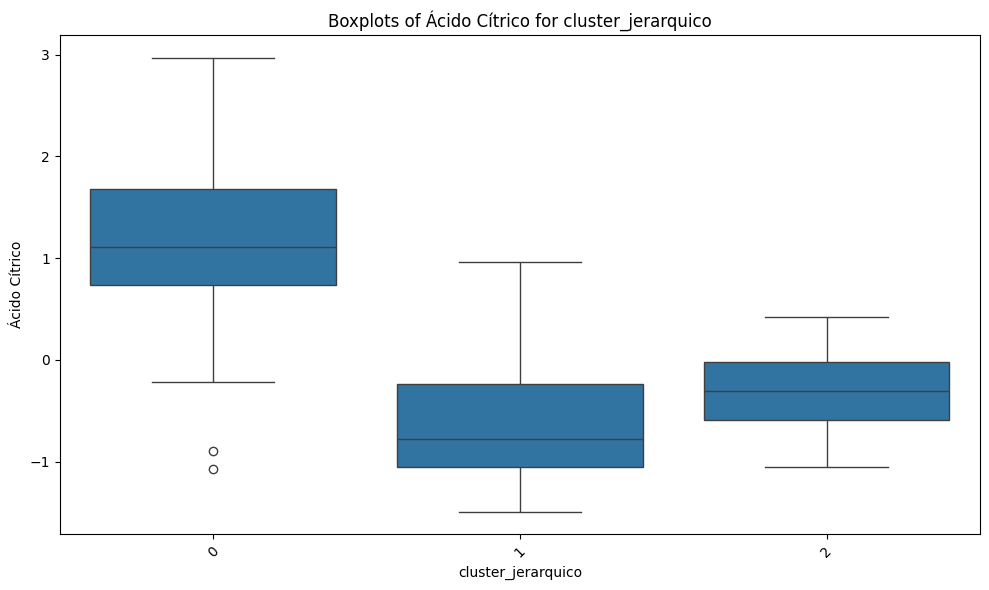

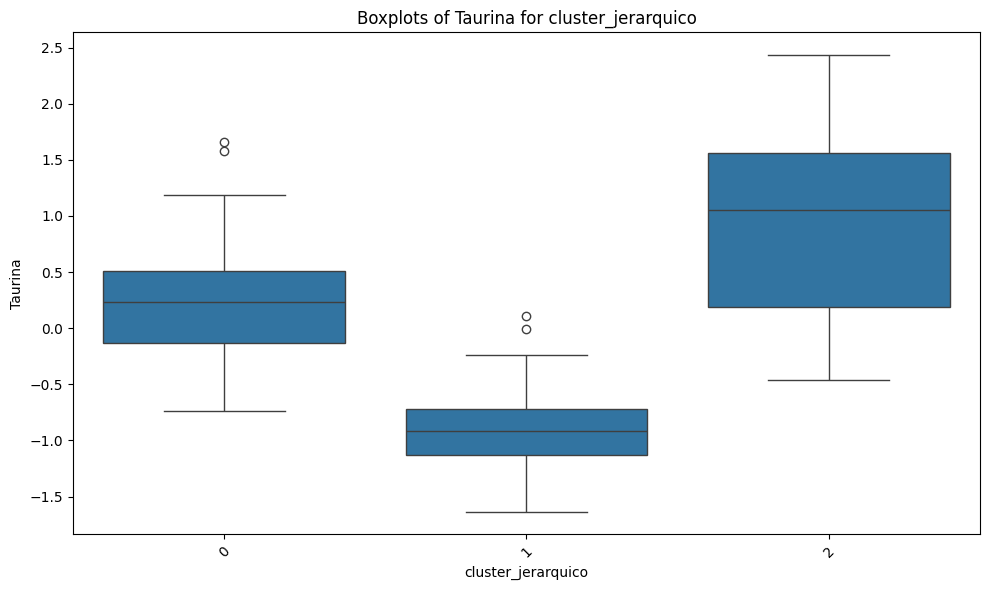

In [15]:
# Boxplots por cluster (jerarquico) para ver como se caracteriza cada segmento
# usando el viztool de boxplots agrupados
for col in features:
    bvt.plot_grouped_boxplots(df_plot, "cluster_jerarquico", col)

**Conclusión**

- Ambos modelos coinciden en **3 segmentos**, lo que refuerza el resultado y encaja con lo que esperaban los químicos (mínimo 3).
- El **jerárquico** asigna todas las mezclas a un grupo y, gracias al dendrograma, nos dice **qué segmentos se parecen más entre sí** (los que se unen a menor altura) — justo el extra que pedían.
- **DBSCAN** además marca como **ruido** unas cuantas mezclas (etiqueta -1): son mezclas "raras" que no encajan claramente en ningún segmento, algo que el jerárquico no distingue.
- Los boxplots por cluster muestran que los segmentos se diferencian sobre todo en el bloque de `Azúcares` / `Ácido Cítrico` / `Taurina`, coherente con el mini-EDA.

**¿Por qué la comparación es especulativa?** Porque **no tenemos target** (ninguna medida de capacidad antifatiga o preferencia del usuario). Sin una "verdad" contra la que medir, no podemos decir objetivamente qué segmentación es "mejor": solo podemos apoyarnos en métricas internas (silueta) y en la coherencia con lo que esperan los químicos, pero la interpretación final de si los segmentos son útiles la tienen que hacer ellos.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [16]:
nuevos = pd.read_csv("./data/new_experiments.csv", sep="|")
print("Nuevos experimentos:", nuevos.shape)
nuevos

Nuevos experimentos: (6, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043


In [17]:
# Calculamos el centroide de cada segmento del clustering jerarquico
centroides = np.array([X[labels_agg == c].mean(axis=0) for c in sorted(set(labels_agg))])
print("Centroides (uno por segmento):")
print(centroides.round(2))

Centroides (uno por segmento):
[[ 0.89  0.52  1.02  1.1   0.23]
 [-0.87 -0.49  0.02 -0.61 -0.88]
 [ 0.19  0.19 -1.38 -0.3   0.93]]


In [18]:
# Asignamos cada nuevo experimento al centroide (segmento) mas cercano
X_nuevos = nuevos[features].values

distancias_centroides = cdist(X_nuevos, centroides)   # distancia de cada punto a cada centroide
segmento_nuevos = distancias_centroides.argmin(axis=1)  # el mas cercano

nuevos_resultado = nuevos.copy()
nuevos_resultado["segmento_asignado"] = segmento_nuevos
nuevos_resultado

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,segmento_asignado
0,1.481555,0.305159,1.366128,2.239039,0.731870,0
1,0.616869,0.890014,0.583034,0.312420,-0.665332,0
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,1
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,1
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,2
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,2


### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

In [19]:
# Cargamos el target real
power = pd.read_csv("./data/power_results.csv", sep="|")
y_all = power["class"].values

# Los 153 primeros se alinean con los experimentos iniciales
y = y_all[:153]
print("Distribucion de niveles reales (iniciales):", dict(zip(*np.unique(y, return_counts=True))))

Distribucion de niveles reales (iniciales): {np.int64(1): np.int64(56), np.int64(2): np.int64(60), np.int64(3): np.int64(37)}


In [20]:
# Funcion auxiliar: accuracy mapeando cada cluster a su clase real mayoritaria
from scipy.stats import mode

def accuracy_por_mayoria(y_true, labels):
    y_true = np.asarray(y_true)
    labels = np.asarray(labels)
    validos = labels != -1          # excluimos el ruido de DBSCAN
    mapeo = {}
    for c in set(labels[validos]):
        clases = y_true[validos][labels[validos] == c]
        mapeo[c] = mode(clases, keepdims=True).mode[0]
    pred = np.array([mapeo.get(l, -99) for l in labels])
    return accuracy_score(y_true[validos], pred[validos])

In [21]:
# Evaluamos el clustering JERARQUICO
print("=== Clustering jerarquico (k=3) ===")
print("ARI      :", round(adjusted_rand_score(y, labels_agg), 3))
print("Accuracy :", round(accuracy_por_mayoria(y, labels_agg), 3))

# Evaluamos DBSCAN (excluyendo el ruido)
mask = labels_db != -1
print("\n=== DBSCAN (excluyendo ruido) ===")
print("Puntos de ruido no evaluados:", (~mask).sum())
print("ARI      :", round(adjusted_rand_score(y[mask], labels_db[mask]), 3))
print("Accuracy :", round(accuracy_por_mayoria(y, labels_db), 3))

=== Clustering jerarquico (k=3) ===
ARI      : 0.816
Accuracy : 0.941

=== DBSCAN (excluyendo ruido) ===
Puntos de ruido no evaluados: 22
ARI      : 0.954
Accuracy : 0.985


In [22]:
# Comprobamos tambien los 6 nuevos experimentos de la Parte II contra su nivel real
y_nuevos = y_all[153:]
print("Nivel real de los nuevos:", y_nuevos)
print("Segmento asignado       :", segmento_nuevos)
# (los numeros de segmento no tienen por que coincidir con las etiquetas 1/2/3,
#  pero deberia haber una correspondencia clara segmento -> nivel)

Nivel real de los nuevos: [1 1 2 2 3 3]
Segmento asignado       : [0 0 1 1 2 2]


**Conclusión Parte III:**

Ambos modelos segmentan muy bien: el ARI es alto y, al mapear cada cluster a su nivel mayoritario, el accuracy supera el 90%. **DBSCAN sale algo mejor** entre los puntos que sí clasifica (deja fuera como ruido las mezclas más ambiguas, y sobre el resto acierta casi siempre), mientras que el **jerárquico** clasifica todo pero con algún error más en las fronteras. Lo importante: aunque construimos los modelos **sin target**, la segmentación que encontraron se corresponde muy bien con los niveles de energización reales, así que la intuición de los químicos y el clustering iban bien encaminados.